In [5]:
# Fase 1 — Carga y Exploración (CRISP-DM: Comprensión de datos)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/PROYECTO CAPSTONE/dataset.csv')
print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras filas:")
df.head()

Shape: (24731, 19)

Columnas: ['timestamp', 'temp_nozzle', 'target_nozzle', 'temp_cama', 'target_cama', 'velocidad', 'flujo', 'pos_x', 'pos_y', 'pos_z', 'capa_actual', 'total_capas', 'progreso', 'vibracion_x', 'vibracion_y', 'corriente_motor', 'estado', 'tipo_falla', 'etiqueta']

Primeras filas:


,timestamp,temp_nozzle,target_nozzle,temp_cama,target_cama,velocidad,flujo,pos_x,pos_y,pos_z,capa_actual,total_capas,progreso,vibracion_x,vibracion_y,corriente_motor,estado,tipo_falla,etiqueta
0,2026-04-03 11:47:23,200.39,200.0,58.33,60.0,52.50,102.86,137.116,122.629,0.4,2,150,0.67,0.1355,0.0555,0.862,Printing,normal,0
1,2026-04-03 11:47:24,199.49,200.0,60.13,60.0,48.25,105.43,133.071,123.859,0.4,2,150,1.33,0.0128,0.0545,0.869,Printing,normal,0
2,2026-04-03 11:47:26,201.84,200.0,59.57,60.0,45.63,99.37,134.430,115.506,0.4,2,150,1.33,0.1013,0.0797,0.741,Printing,normal,0
3,2026-04-03 11:47:28,199.37,200.0,58.91,60.0,50.64,98.11,140.376,106.866,0.4,2,150,1.33,0.0991,0.1816,0.821,Printing,normal,0
4,2026-04-03 11:47:31,200.15,200.0,60.27,60.0,53.87,102.17,140.789,106.723,0.4,2,150,1.33,0.0786,0.0134,0.834,Printing,normal,0


In [7]:
print("=" * 50)
print("EXPLORACIÓN INICIAL")
print("=" * 50)

print(f"\nRegistros totales: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nValores nulos:")
print(df.isnull().sum())

print(f"\nDuplicados: {df.duplicated().sum()}")

print(f"\nDistribución de clases:")
print(df['tipo_falla'].value_counts())
print(f"\nBalance binario:")
print(df['etiqueta'].value_counts(normalize=True).round(3) * 100)

EXPLORACIÓN INICIAL

Registros totales: 24,731
Variables: 19

Tipos de datos:
timestamp           object
temp_nozzle        float64
target_nozzle      float64
temp_cama          float64
target_cama        float64
velocidad          float64
flujo              float64
pos_x              float64
pos_y              float64
pos_z              float64
capa_actual          int64
total_capas          int64
progreso           float64
vibracion_x        float64
vibracion_y        float64
corriente_motor    float64
estado              object
tipo_falla          object
etiqueta             int64
dtype: object

Valores nulos:
timestamp          0
temp_nozzle        0
target_nozzle      0
temp_cama          0
target_cama        0
velocidad          0
flujo              0
pos_x              0
pos_y              0
pos_z              0
capa_actual        0
total_capas        0
progreso           0
vibracion_x        0
vibracion_y        0
corriente_motor    0
estado             0
tipo_falla         0
e

In [8]:
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)

df.describe().round(2)

ESTADÍSTICAS DESCRIPTIVAS


,temp_nozzle,target_nozzle,temp_cama,target_cama,velocidad,flujo,pos_x,pos_y,pos_z,capa_actual,total_capas,progreso,vibracion_x,vibracion_y,corriente_motor,etiqueta
count,24731.00,24731.0,24731.00,24731.0,24731.00,24731.00,24731.00,24731.00,24731.00,24731.00,24731.0,24731.00,24731.00,24731.00,24731.00,24731.00
mean,200.17,200.0,59.94,60.0,49.53,99.21,113.49,119.23,19.79,98.97,150.0,65.96,0.11,0.10,0.81,0.17
std,2.16,0.0,1.29,0.0,4.29,4.58,57.96,51.99,9.90,49.52,0.0,33.02,0.14,0.13,0.07,0.38
min,179.51,200.0,49.66,60.0,31.28,62.91,0.00,-0.42,0.40,2.00,150.0,0.67,0.00,0.00,0.47,0.00
25%,199.05,200.0,59.31,60.0,46.71,97.92,68.60,81.31,11.20,56.00,150.0,37.33,0.04,0.04,0.76,0.00
50%,200.08,200.0,59.98,60.0,49.61,99.82,111.79,121.67,22.00,110.00,150.0,72.67,0.07,0.07,0.80,0.00
75%,201.12,200.0,60.64,60.0,52.45,101.63,160.55,159.15,30.00,150.00,150.0,100.00,0.11,0.10,0.85,0.00
max,218.53,200.0,69.01,60.0,66.87,114.75,221.36,221.06,30.00,150.00,150.0,100.00,1.04,1.01,1.26,1.00


In [9]:
# Fase 2 — Visualizaciones (CRISP-DM: Comprensión de datos)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Librerías cargadas ")

Librerías cargadas 


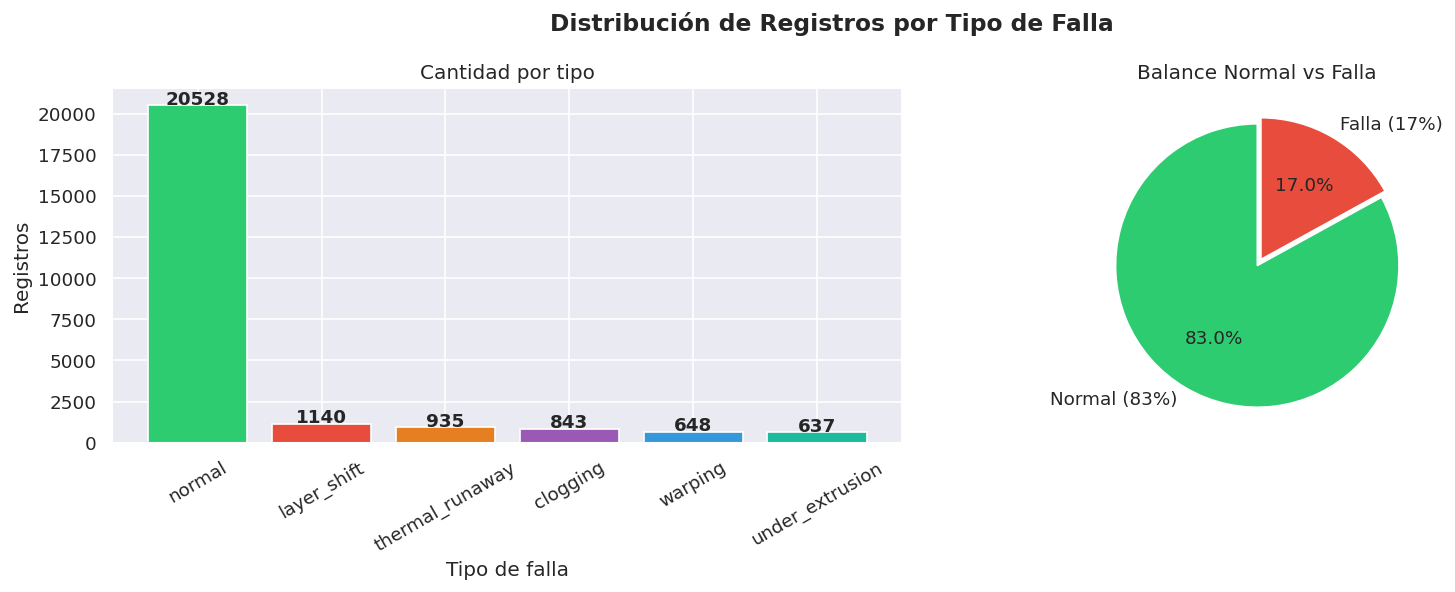

Gráfico guardado 


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Registros por Tipo de Falla', fontsize=14, fontweight='bold')

# Gráfico 1: conteo por tipo
colores = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6', '#3498db', '#1abc9c']
conteo = df['tipo_falla'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=colores)
axes[0].set_title('Cantidad por tipo')
axes[0].set_xlabel('Tipo de falla')
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico 2: pie chart binario
binario = df['etiqueta'].value_counts()
axes[1].pie(binario.values, labels=['Normal (83%)', 'Falla (17%)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Balance Normal vs Falla')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/distribucion_fallas.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado ")

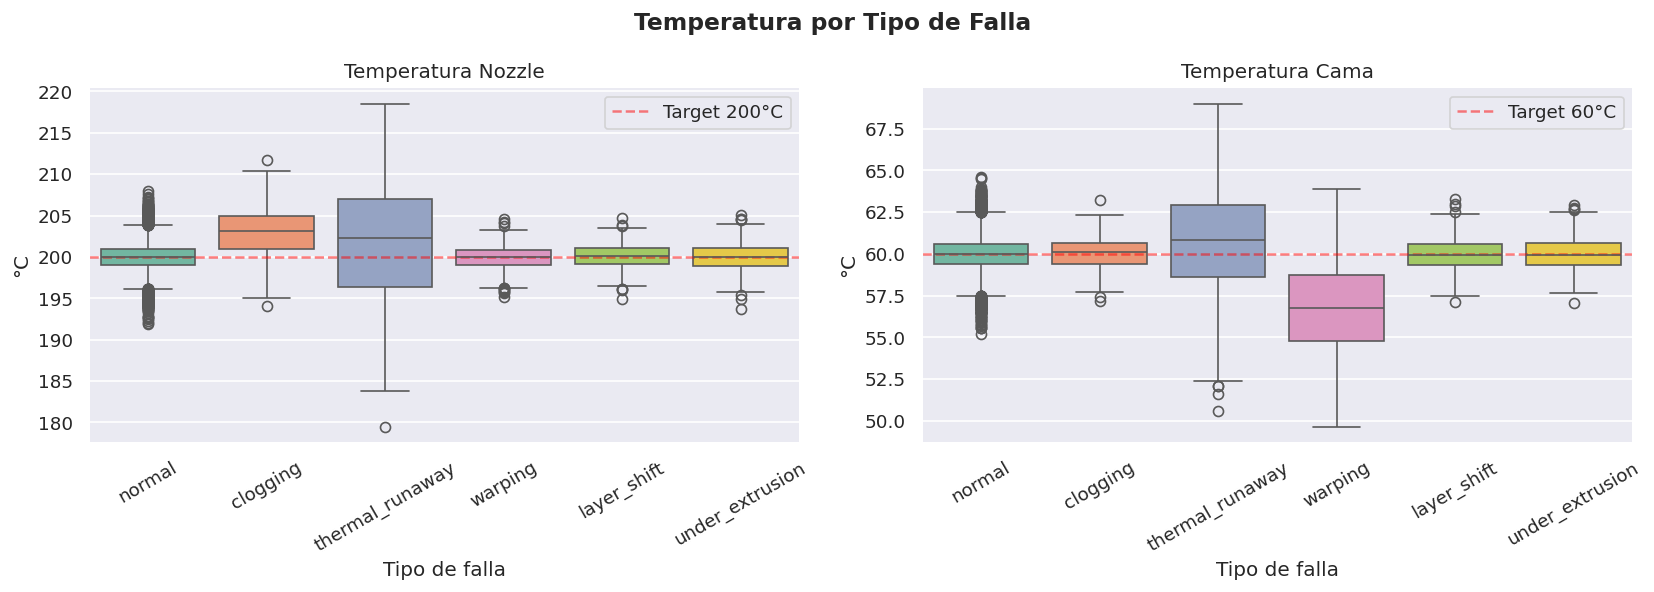

Gráfico guardado


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temperatura por Tipo de Falla', fontsize=14, fontweight='bold')

orden = ['normal', 'clogging', 'thermal_runaway', 'warping', 'layer_shift', 'under_extrusion']

sns.boxplot(data=df, x='tipo_falla', y='temp_nozzle', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Temperatura Nozzle')
axes[0].set_xlabel('Tipo de falla')
axes[0].set_ylabel('°C')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Target 200°C')
axes[0].legend()

sns.boxplot(data=df, x='tipo_falla', y='temp_cama', order=orden,
            palette='Set2', ax=axes[1])
axes[1].set_title('Temperatura Cama')
axes[1].set_xlabel('Tipo de falla')
axes[1].set_ylabel('°C')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=60, color='red', linestyle='--', alpha=0.5, label='Target 60°C')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/temperaturas_fallas.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

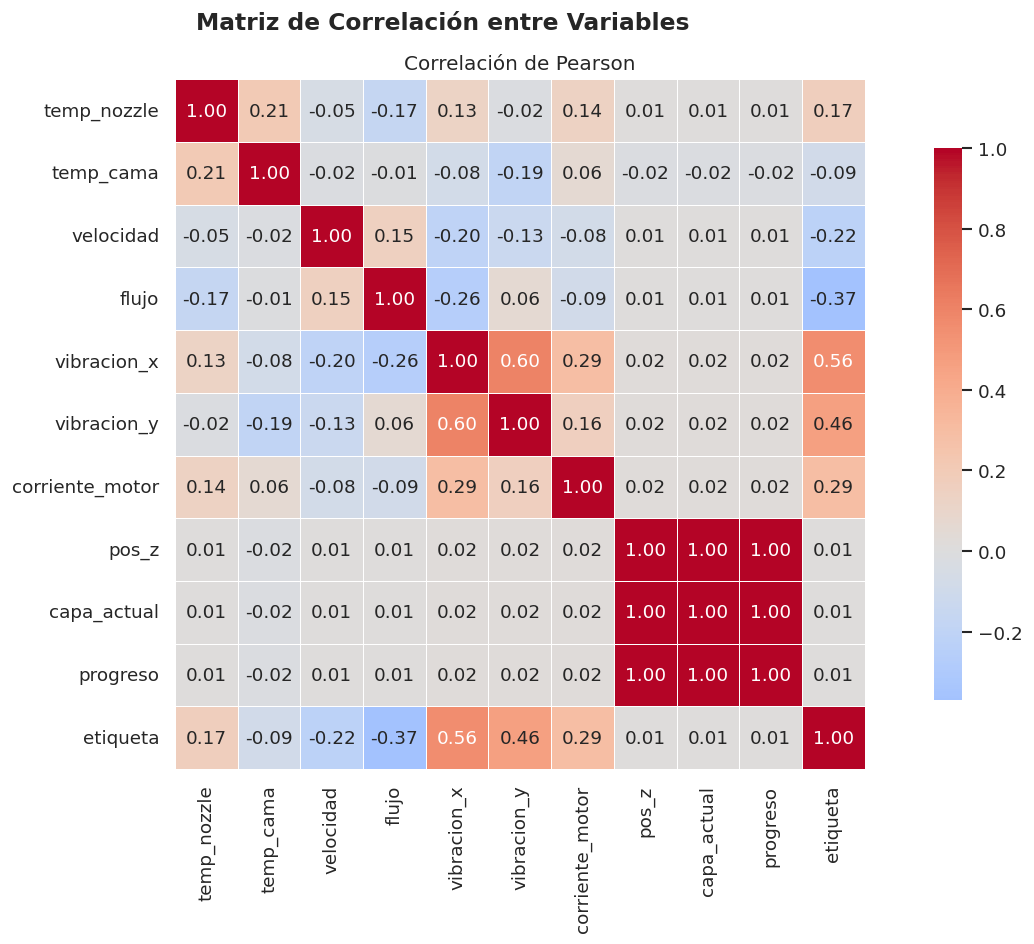

Gráfico guardado


In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold')

features_numericas = ['temp_nozzle', 'temp_cama', 'velocidad', 'flujo',
                      'vibracion_x', 'vibracion_y', 'corriente_motor',
                      'pos_z', 'capa_actual', 'progreso', 'etiqueta']

corr = df[features_numericas].corr().round(2)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

ax.set_title('Correlación de Pearson')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/correlacion.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

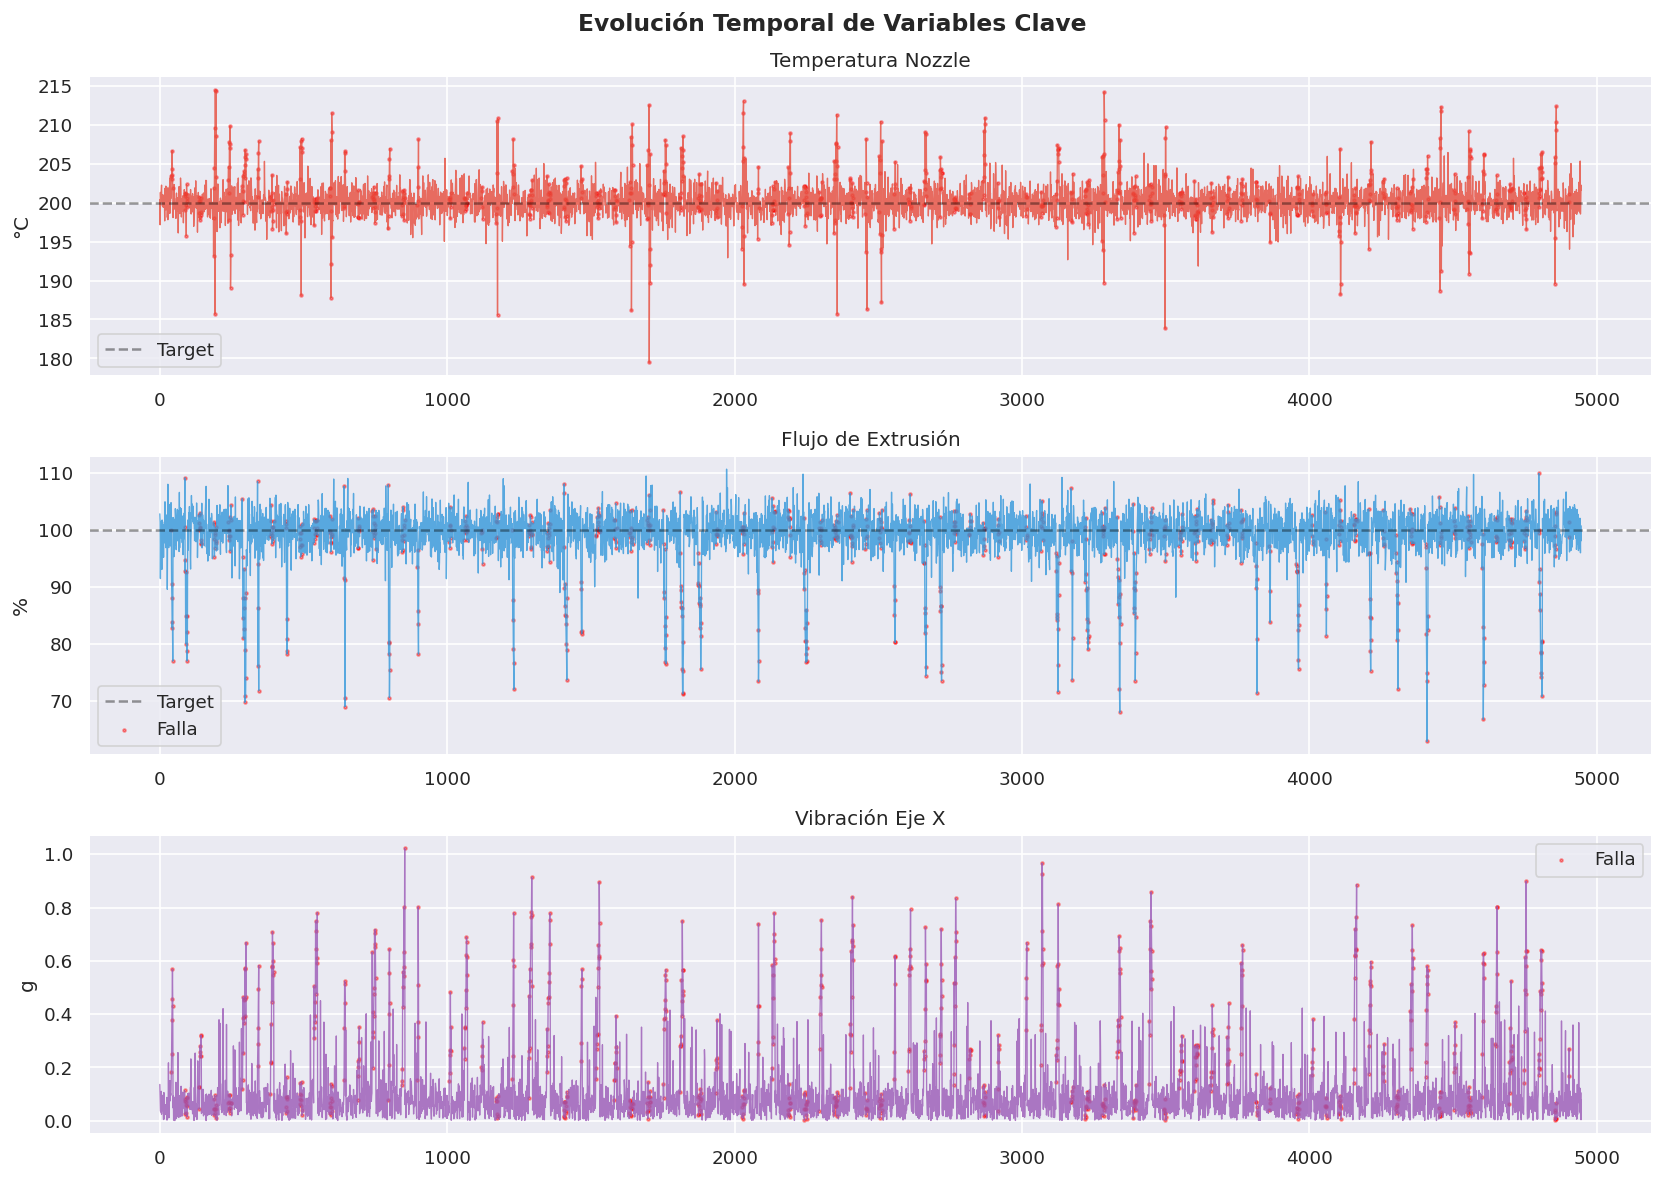

Gráfico guardado


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Evolución Temporal de Variables Clave', fontsize=14, fontweight='bold')

muestra = df.iloc[::5].reset_index(drop=True)

axes[0].plot(muestra.index, muestra['temp_nozzle'], color='#e74c3c', linewidth=0.8, alpha=0.8)
axes[0].axhline(y=200, color='black', linestyle='--', alpha=0.4, label='Target')
axes[0].set_ylabel('°C')
axes[0].set_title('Temperatura Nozzle')
axes[0].legend()

# Marcar zonas de falla
fallas_idx = muestra[muestra['etiqueta'] == 1].index
axes[0].scatter(fallas_idx, muestra.loc[fallas_idx, 'temp_nozzle'],
                color='red', s=3, alpha=0.4, label='Falla')

axes[1].plot(muestra.index, muestra['flujo'], color='#3498db', linewidth=0.8, alpha=0.8)
axes[1].axhline(y=100, color='black', linestyle='--', alpha=0.4, label='Target')
axes[1].set_ylabel('%')
axes[1].set_title('Flujo de Extrusión')
fallas_idx = muestra[muestra['etiqueta'] == 1].index
axes[1].scatter(fallas_idx, muestra.loc[fallas_idx, 'flujo'],
                color='red', s=3, alpha=0.4, label='Falla')
axes[1].legend()

axes[2].plot(muestra.index, muestra['vibracion_x'], color='#9b59b6', linewidth=0.8, alpha=0.8)
axes[2].set_ylabel('g')
axes[2].set_title('Vibración Eje X')
fallas_idx = muestra[muestra['etiqueta'] == 1].index
axes[2].scatter(fallas_idx, muestra.loc[fallas_idx, 'vibracion_x'],
                color='red', s=3, alpha=0.4, label='Falla')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/evolucion_temporal.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

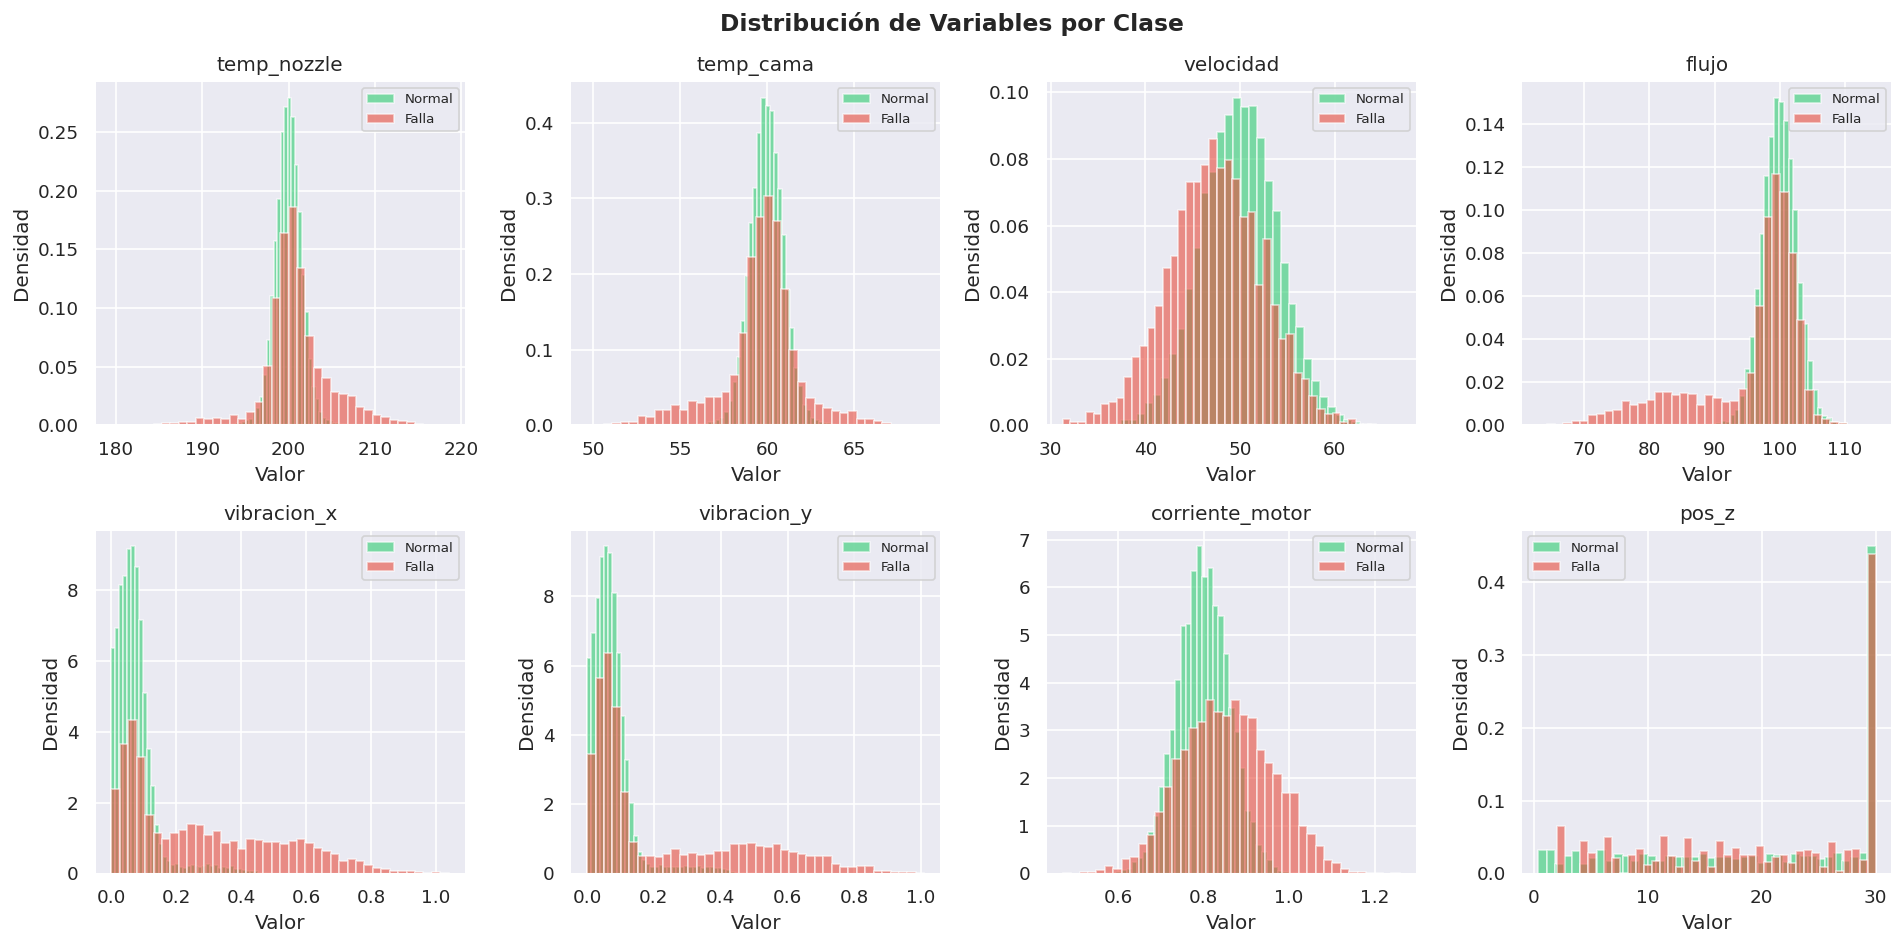

Gráfico guardado


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de Variables por Clase', fontsize=14, fontweight='bold')

features = ['temp_nozzle', 'temp_cama', 'velocidad', 'flujo',
            'vibracion_x', 'vibracion_y', 'corriente_motor', 'pos_z']

colores = {'normal': '#2ecc71', 'falla': '#e74c3c'}

for ax, feature in zip(axes.flatten(), features):
    normal = df[df['etiqueta'] == 0][feature]
    falla  = df[df['etiqueta'] == 1][feature]
    ax.hist(normal, bins=40, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(falla,  bins=40, alpha=0.6, color='#e74c3c', label='Falla',  density=True)
    ax.set_title(feature)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/histogramas.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

In [16]:
# Fase 3 — Preprocesamiento (CRISP-DM: Preparación de datos)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print("=" * 50)
print("PREPROCESAMIENTO")
print("=" * 50)

cols_eliminar = ['timestamp', 'estado', 'target_nozzle', 'target_cama', 'total_capas']
df_ml = df.drop(columns=cols_eliminar)
print(f"Columnas eliminadas: {cols_eliminar}")

le = LabelEncoder()
df_ml['tipo_falla_enc'] = le.fit_transform(df_ml['tipo_falla'])
print(f"\nClases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_ml.drop(columns=['tipo_falla', 'tipo_falla_enc', 'etiqueta'])
y_binario    = df_ml['etiqueta']
y_multiclase = df_ml['tipo_falla_enc']

print(f"\nFeatures: {list(X.columns)}")
print(f"Shape X: {X.shape}")

X_train, X_test, y_bin_train, y_bin_test, y_mul_train, y_mul_test = train_test_split(
    X, y_binario, y_multiclase,
    test_size=0.20, random_state=42, stratify=y_binario
)

print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Escalado aplicado")
print("\nPreprocesamiento completo")

PREPROCESAMIENTO
Columnas eliminadas: ['timestamp', 'estado', 'target_nozzle', 'target_cama', 'total_capas']

Clases codificadas: {'clogging': np.int64(0), 'layer_shift': np.int64(1), 'normal': np.int64(2), 'thermal_runaway': np.int64(3), 'under_extrusion': np.int64(4), 'warping': np.int64(5)}

Features: ['temp_nozzle', 'temp_cama', 'velocidad', 'flujo', 'pos_x', 'pos_y', 'pos_z', 'capa_actual', 'progreso', 'vibracion_x', 'vibracion_y', 'corriente_motor']
Shape X: (24731, 12)

Train: 19,784 | Test: 4,947
Escalado aplicado

Preprocesamiento completo


In [17]:
# Fase 4 — Entrenamiento (CRISP-DM: Modelado)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("=" * 50)
print("MODELO 1 — Logistic Regression (Baseline)")
print("=" * 50)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_bin_train)

y_pred_lr = lr.predict(X_test_sc)
acc_lr = accuracy_score(y_bin_test, y_pred_lr)

print(f"\nAccuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"\nReporte de clasificación:")
print(classification_report(y_bin_test, y_pred_lr, target_names=['Normal', 'Falla']))

MODELO 1 — Logistic Regression (Baseline)

Accuracy: 0.9216 (92.16%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95      4106
       Falla       0.89      0.62      0.73       841

    accuracy                           0.92      4947
   macro avg       0.91      0.80      0.84      4947
weighted avg       0.92      0.92      0.92      4947



In [18]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("MODELO 2 — Random Forest")
print("=" * 50)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_bin_train)

y_pred_rf = rf.predict(X_test_sc)
acc_rf = accuracy_score(y_bin_test, y_pred_rf)

print(f"\nAccuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"\nReporte de clasificación:")
print(classification_report(y_bin_test, y_pred_rf, target_names=['Normal', 'Falla']))

MODELO 2 — Random Forest

Accuracy: 0.9628 (96.28%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      4106
       Falla       0.95      0.83      0.88       841

    accuracy                           0.96      4947
   macro avg       0.96      0.91      0.93      4947
weighted avg       0.96      0.96      0.96      4947



In [19]:
from xgboost import XGBClassifier

print("=" * 50)
print("MODELO 3 — XGBoost")
print("=" * 50)

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_sc, y_bin_train)

y_pred_xgb = xgb.predict(X_test_sc)
acc_xgb = accuracy_score(y_bin_test, y_pred_xgb)

print(f"\nAccuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")
print(f"\nReporte de clasificación:")
print(classification_report(y_bin_test, y_pred_xgb, target_names=['Normal', 'Falla']))

MODELO 3 — XGBoost

Accuracy: 0.9715 (97.15%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      4106
       Falla       0.96      0.87      0.91       841

    accuracy                           0.97      4947
   macro avg       0.97      0.93      0.95      4947
weighted avg       0.97      0.97      0.97      4947



In [24]:
from tensorflow.keras.layers import BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import numpy as np

print("=" * 50)
print("MODELO 4 — Red Neuronal MLP")
print("=" * 50)

tf.keras.backend.clear_session()

# Class weights
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_bin_train)
class_weights = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weights}")

model_mlp = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_mlp.summary()

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = model_mlp.fit(
    X_train_sc, y_bin_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

MODELO 4 — Red Neuronal MLP
Class weights: {0: np.float64(0.6023626842041164), 1: np.float64(2.942296252230815)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8641 - loss: 0.3454 - val_accuracy: 0.9394 - val_loss: 0.2035
Epoch 2/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9084 - loss: 0.2863 - val_accuracy: 0.9353 - val_loss: 0.1949
Epoch 3/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9126 - loss: 0.2710 - val_accuracy: 0.9419 - val_loss: 0.1899
Epoch 4/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9169 - loss: 0.2669 - val_accuracy: 0.9343 - val_loss: 0.1993
Epoch 5/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9180 - loss: 0.2563 - val_accuracy: 0.9358 - val_loss: 0.1976
Epoch 6/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9219 - loss: 0.2499 - val_accuracy: 0.9414 - val_loss: 0.1962
Epoch 7/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9238 - loss: 0.2439 - val_accuracy: 0.9368 - val_loss: 0.1982
Epoch 8/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9241 - loss: 0.2409 - val_accuracy:

In [25]:
y_pred_mlp_prob = model_mlp.predict(X_test_sc)
y_pred_mlp = (y_pred_mlp_prob > 0.5).astype(int).flatten()
acc_mlp = accuracy_score(y_bin_test, y_pred_mlp)

print(f"Accuracy: {acc_mlp:.4f} ({acc_mlp*100:.2f}%)")
print(f"\nReporte de clasificación:")
print(classification_report(y_bin_test, y_pred_mlp, target_names=['Normal', 'Falla']))

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9420 (94.20%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96      4106
       Falla       0.81      0.86      0.83       841

    accuracy                           0.94      4947
   macro avg       0.89      0.91      0.90      4947
weighted avg       0.94      0.94      0.94      4947



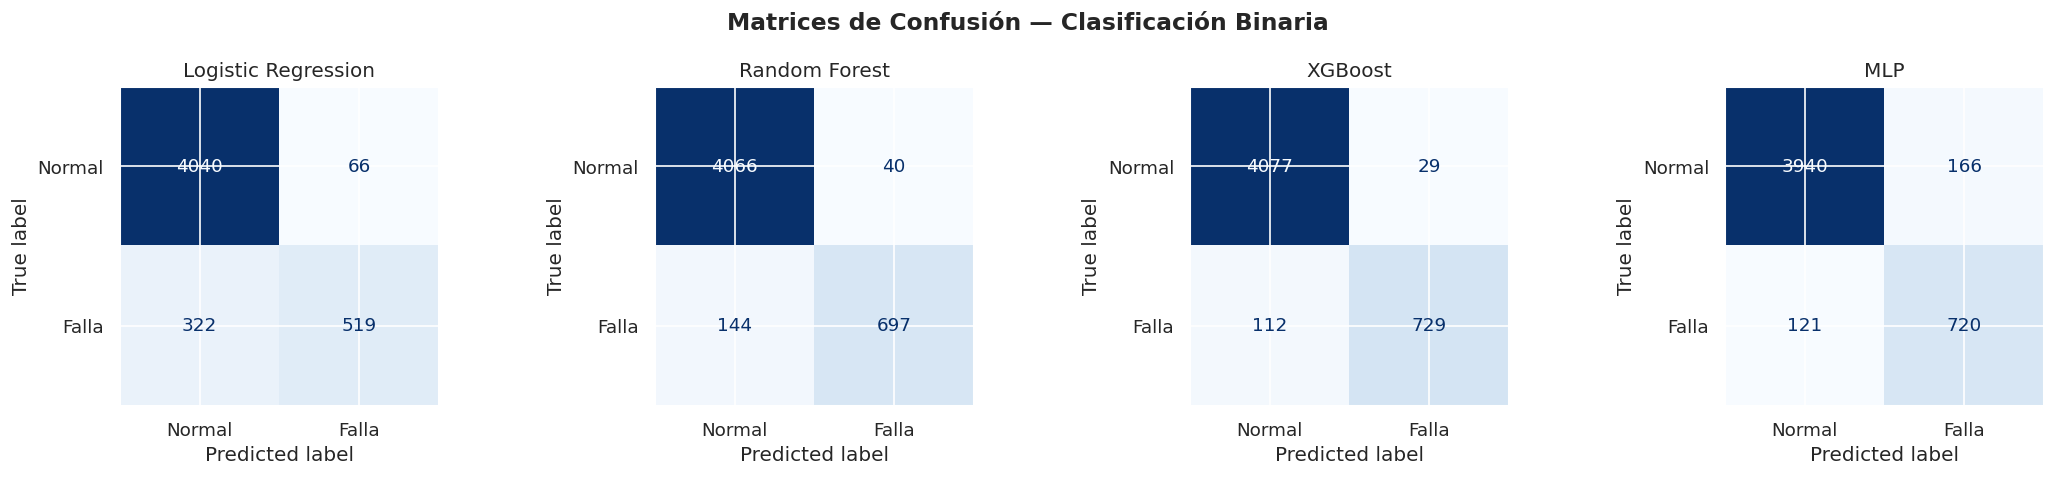

Gráfico guardado


In [26]:
# Fase 5 — Evaluación (CRISP-DM: Evaluación)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Matrices de Confusión — Clasificación Binaria', fontsize=14, fontweight='bold')

modelos = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
    ('MLP',                 y_pred_mlp),
]

for ax, (nombre, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_bin_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Falla'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

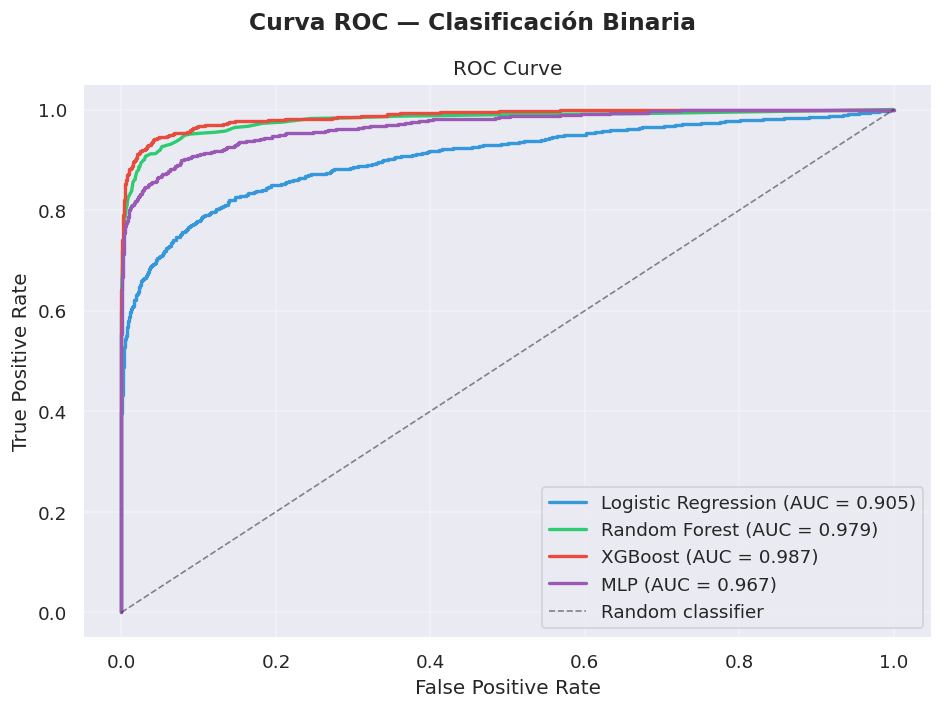

Gráfico guardado


In [27]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Curva ROC — Clasificación Binaria', fontsize=14, fontweight='bold')

modelos_roc = [
    ('Logistic Regression', lr.predict_proba(X_test_sc)[:, 1]),
    ('Random Forest',       rf.predict_proba(X_test_sc)[:, 1]),
    ('XGBoost',             xgb.predict_proba(X_test_sc)[:, 1]),
    ('MLP',                 y_pred_mlp_prob.flatten()),
]

colores = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for (nombre, probs), color in zip(modelos_roc, colores):
    fpr, tpr, _ = roc_curve(y_bin_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/roc_binaria.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

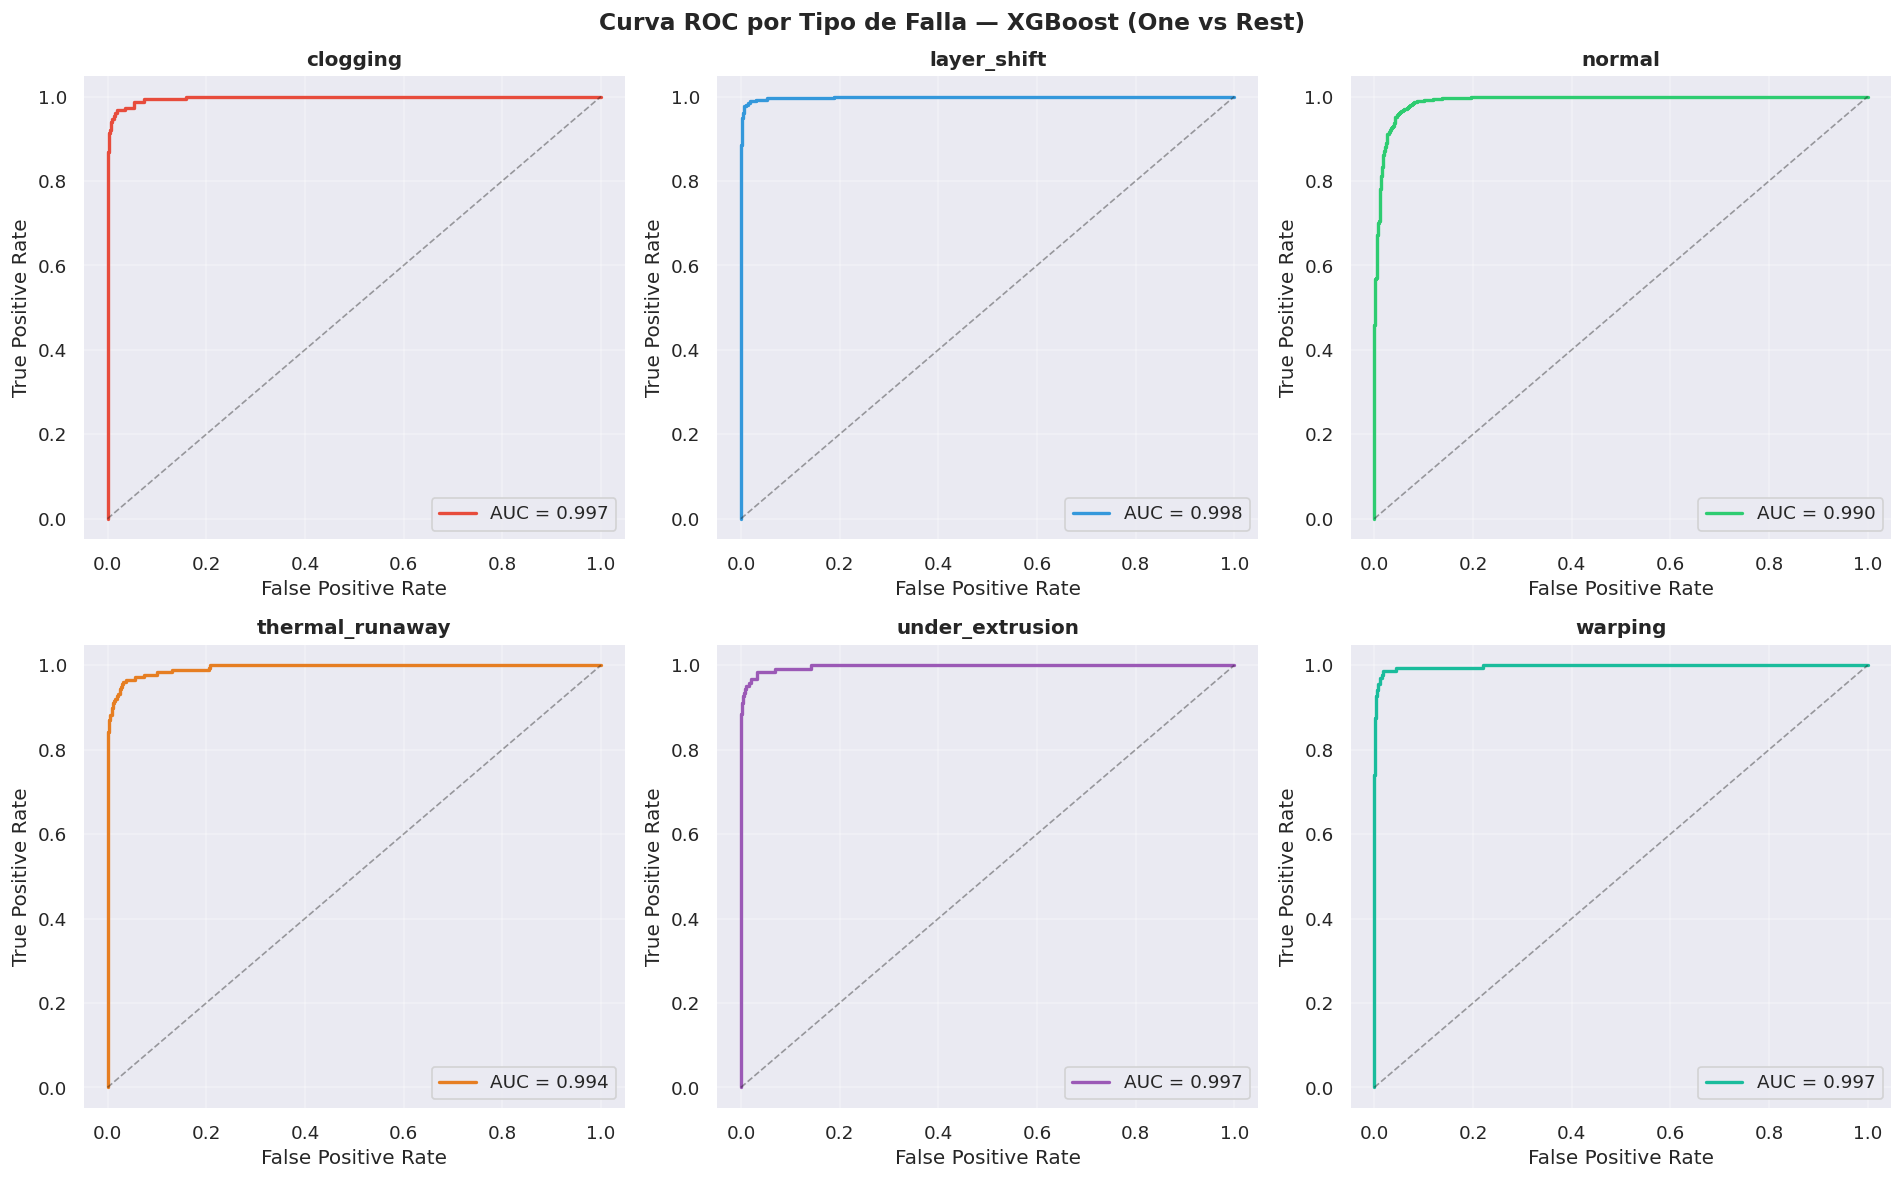

Gráfico guardado


In [28]:
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

clases = list(le.classes_)
n_clases = len(clases)

y_mul_test_bin = label_binarize(y_mul_test, classes=range(n_clases))

xgb_multi = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='mlogloss', objective='multi:softprob')
xgb_multi.fit(X_train_sc, y_mul_train)
y_score = xgb_multi.predict_proba(X_test_sc)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curva ROC por Tipo de Falla — XGBoost (One vs Rest)', fontsize=14, fontweight='bold')

colores_multi = ['#e74c3c','#3498db','#2ecc71','#e67e22','#9b59b6','#1abc9c']

for idx, (clase, color) in enumerate(zip(clases, colores_multi)):
    ax = axes[idx // 3][idx % 3]
    fpr, tpr, _ = roc_curve(y_mul_test_bin[:, idx], y_score[:, idx])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
    ax.set_title(f'{clase}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/roc_por_falla.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

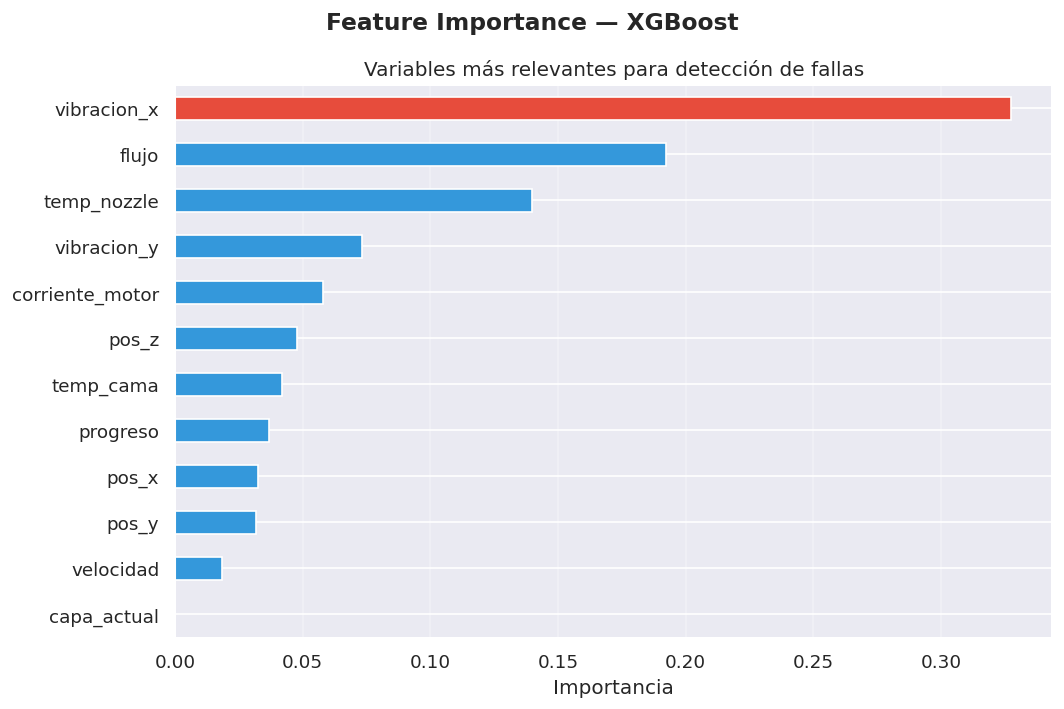

Gráfico guardado


In [29]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Feature Importance — XGBoost', fontsize=14, fontweight='bold')

importancias = pd.Series(xgb.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

colores = ['#e74c3c' if v == importancias.max() else '#3498db' for v in importancias]
importancias.plot(kind='barh', ax=ax, color=colores)

ax.set_xlabel('Importancia')
ax.set_title('Variables más relevantes para detección de fallas')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/feature_importance.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado")

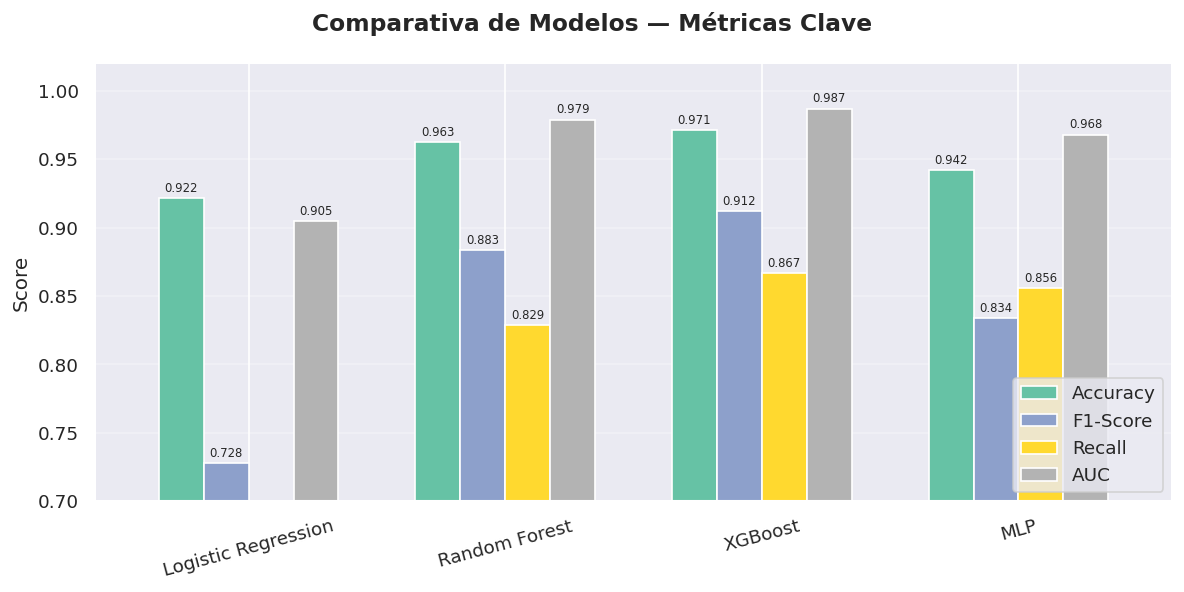


Tabla resumen:
             Modelo  Accuracy  F1-Score  Recall   AUC
Logistic Regression    0.9216    0.7279  0.6171 0.905
      Random Forest    0.9628    0.8834  0.8288 0.979
            XGBoost    0.9715    0.9118  0.8668 0.987
                MLP    0.9420    0.8338  0.8561 0.968

Gráfico guardado


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Comparativa de Modelos — Métricas Clave', fontsize=14, fontweight='bold')

from sklearn.metrics import f1_score, precision_score, recall_score

resultados = {
    'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy': [
        accuracy_score(y_bin_test, y_pred_lr),
        accuracy_score(y_bin_test, y_pred_rf),
        accuracy_score(y_bin_test, y_pred_xgb),
        accuracy_score(y_bin_test, y_pred_mlp),
    ],
    'F1-Score': [
        f1_score(y_bin_test, y_pred_lr),
        f1_score(y_bin_test, y_pred_rf),
        f1_score(y_bin_test, y_pred_xgb),
        f1_score(y_bin_test, y_pred_mlp),
    ],
    'Recall': [
        recall_score(y_bin_test, y_pred_lr),
        recall_score(y_bin_test, y_pred_rf),
        recall_score(y_bin_test, y_pred_xgb),
        recall_score(y_bin_test, y_pred_mlp),
    ],
    'AUC': [0.905, 0.979, 0.987, 0.968]
}

df_res = pd.DataFrame(resultados)
df_res_plot = df_res.set_index('Modelo')

df_res_plot.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PROYECTO CAPSTONE/comparativa_modelos.png', bbox_inches='tight')
plt.show()

print("\nTabla resumen:")
print(df_res.round(4).to_string(index=False))
print("\nGráfico guardado")

In [31]:
# Fase 6 — Exportar modelos (CRISP-DM: Evaluación)
import pickle
import os

ruta = '/content/drive/MyDrive/PROYECTO CAPSTONE/modelos/'
os.makedirs(ruta, exist_ok=True)

with open(ruta + 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open(ruta + 'random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open(ruta + 'xgboost.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open(ruta + 'mlp.pkl', 'wb') as f:
    pickle.dump(model_mlp, f)

with open(ruta + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(ruta + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Modelos exportados:")
for archivo in os.listdir(ruta):
    print(f"  ✓ {archivo}")
print("\nFase 6 completa")

Modelos exportados:
  ✓ logistic_regression.pkl
  ✓ random_forest.pkl
  ✓ xgboost.pkl
  ✓ mlp.pkl
  ✓ scaler.pkl
  ✓ label_encoder.pkl

Fase 6 completa
